In [1]:
import requests

In [2]:
url = "https://traveltriangle.com/tour-packages/india/page/1"

from curl_cffi import requests 

response = requests.get(url, impersonate = "chrome110")
response

<Response [200]>

'<!doctype html><html lang="en" data-reactroot=""><head><link href="https://assets.traveltriangle.com" rel="dns-prefetch"/><link href="https://fonts.gstatic.com" rel="dns-prefetch"/><link href="https://www.googletagmanager.com" rel="dns-prefetch"/><link href="https://connect.facebook.net" rel="dns-prefetch"/><link href="https://www.google-analytics.com" rel="dns-prefetch"/><link href="//www.googleadservices.com" rel="dns-prefetch"/><link rel="preload" href="https://fonts.gstatic.com/s/lato/v13/qIIYRU-oROkIk8vfvxw6QvesZW2xOQ-xsNqO47m55DA.woff" as="font" type="font/woff2" crossorigin="anonymous"/><link rel="preload" as="script" href="https://assets.traveltriangle.com/desktop_assets/build/runtime-b6b31397af368af98f7c.js" charSet="UTF-8"/><link rel="preload" as="script" href="https://assets.traveltriangle.com/desktop_assets/build/vendor-react-03b39ad1fcca23b5a27e.js" charSet="UTF-8"/><link rel="preload" as="script" href="https://assets.traveltriangle.com/desktop_assets/build/vendor-chunks-
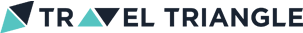

In [3]:
response.text

In [4]:
!pip install bs4

Defaulting to user installation because normal site-packages is not writeable


In [5]:
html_code=response.text

In [6]:
from bs4 import BeautifulSoup

In [7]:
soup=BeautifulSoup(html_code)

In [8]:
Name= soup.find_all('p', class_="col-md-12 pl0 fw9 m0 f16 pfc3 at_packageName")
print(len(Name))

20


In [9]:
print(soup.prettify()[:1000])  # print first 1000 chars

<!DOCTYPE html>
<html data-reactroot="" lang="en">
 <head>
  <link href="https://assets.traveltriangle.com" rel="dns-prefetch"/>
  <link href="https://fonts.gstatic.com" rel="dns-prefetch"/>
  <link href="https://www.googletagmanager.com" rel="dns-prefetch"/>
  <link href="https://connect.facebook.net" rel="dns-prefetch"/>
  <link href="https://www.google-analytics.com" rel="dns-prefetch"/>
  <link href="//www.googleadservices.com" rel="dns-prefetch"/>
  <link as="font" crossorigin="anonymous" href="https://fonts.gstatic.com/s/lato/v13/qIIYRU-oROkIk8vfvxw6QvesZW2xOQ-xsNqO47m55DA.woff" rel="preload" type="font/woff2"/>
  <link as="script" charset="UTF-8" href="https://assets.traveltriangle.com/desktop_assets/build/runtime-b6b31397af368af98f7c.js" rel="preload"/>
  <link as="script" charset="UTF-8" href="https://assets.traveltriangle.com/desktop_assets/build/vendor-react-03b39ad1fcca23b5a27e.js" rel="preload"/>
  <link as="script" charset="UTF-8" href="https://assets.traveltriangle.com/d

In [10]:
name_data=[]
price_data=[]
duration_data=[]
discount_data=[]
# cities_data=[]
# hotel_star_data=[]
explore_data=[]

for i in range(1,60):
    url =f'https://traveltriangle.com/tour-packages/india/page/{i}'
    headers ={
       "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
    }

    response = requests.get(url,headers=headers)

    html_code= response.text
    soup = BeautifulSoup(html_code, "html.parser")

    containers = soup.find_all('div', class_="packageCard")

    

    name = soup.find_all('p', attrs ={"class":"col-md-12 pl0 fw9 m0 f16 pfc3 at_packageName"})
    for t in name :
        name_data.append(t.text)

    price = soup.find_all('p', attrs={'class':"sfc3 m0 f20 fw9 priceVal at_newprice"})
    for t in price :
        price_data.append(t.text)

    duration = soup.find_all('span', attrs={'class':"iblock sfc6"})
    for t in duration :
        duration_data.append(t.text)

    # Discoun
    # discount = soup.find_all('span', attrs={'class':"f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label"})
    # for t in discount :
    #     discount_data.append(t.text)

    # cities = soup.find_all('li', attrs={'class':"f12"})
    # for t in cities :
    #     cities_data.append(t.text)

    # hotel_star = soup.find_all('p', attrs={'class':"mb0"})
    # for t in hotel_star :
    #     hotel_star_data.append(t.text)

   
    explore = soup.find_all('div', attrs={'class':"f12 pfc4 m0 fw4 at_aboutpackage_text"})
    for t in explore :
        explore_data.append(t.text)

In [11]:
print("Name Data :",len(name_data))
print("Price Data :",len(price_data))
print("Duration Data :",len(duration_data))
# print("Discount Data :",len(discount_data))
# print("Cities Data :",len(cities_data))
# print("Hotel_star Data :",len(hotel_star_data))
print("Explore Data :",len(explore_data))

Name Data : 1180
Price Data : 1180
Duration Data : 1180
Explore Data : 1180


In [12]:
data ={
    "Name" : name_data,
    "Price" :price_data,
    "Duration" : duration_data,
    # "Discount" : discount_data,
    "Explore" : explore_data
}

In [13]:
import pandas as pd 
import numpy as np
df = pd.DataFrame(data)

In [14]:
df

,Name,Price,Duration,Explore
0,Most Reasonable Goa Honeymoon Tour Packages,"₹ 7,999/-₹ 9,142/-",5 Days & 4 Nights,Check out TravelTriangle’s list of 4 nights 5 ...
1,Fantastic Andaman Honeymoon Package,"₹ 15,599/-₹ 18,811/-",5 Days & 4 Nights,Spend your dream honeymoon by booking this 4 n...
2,Romantic Mussoorie Tour Package From Delhi,"₹ 10,500/-₹ 12,000/-",3 Days & 2 Nights,"The tranquil hills beckon you, and this 3 days..."
3,Coorg Package For 2 Nights And 3 Days,"₹ 14,500/-₹ 15,934/-",3 Days & 2 Nights,"Have a surreal experience in Coorg, witness th..."
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,"₹ 33,200/-₹ 36,484/-",5 Days & 4 Nights,"Explore the best of this tropical paradise, ch..."
...,...,...,...,...
1175,North Goa Honeymoon Package,"₹ 19,199/-₹ 21,098/-",5 Days & 4 Nights,Enjoy the enthusiastic and romantic 4 days hon...
1176,Best Selling Matheran Sightseeing Tours Offeri...,"₹ 22,999/-₹ 25,274/-",5 Days & 4 Nights,Check out the best Matheran sightseeing packag...
1177,Explore the many charms of Athirapally & Alleppey,"₹ 8,734/-₹ 9,925/-",3 Days & 2 Nights,"Get to explore Athirapally and Alleppey, the t..."
1178,Amazing Meghalaya Honeymoon Package,"₹ 37,499/-₹ 41,208/-",8 Days & 7 Nights,Set off on a trip to treasure for a lifetime w...


In [15]:
df.to_csv('travel_triangle_data.csv')

In [16]:
df.to_csv('travel_triangle_data.csv', index=False)

In [17]:
df

,Name,Price,Duration,Explore
0,Most Reasonable Goa Honeymoon Tour Packages,"₹ 7,999/-₹ 9,142/-",5 Days & 4 Nights,Check out TravelTriangle’s list of 4 nights 5 ...
1,Fantastic Andaman Honeymoon Package,"₹ 15,599/-₹ 18,811/-",5 Days & 4 Nights,Spend your dream honeymoon by booking this 4 n...
2,Romantic Mussoorie Tour Package From Delhi,"₹ 10,500/-₹ 12,000/-",3 Days & 2 Nights,"The tranquil hills beckon you, and this 3 days..."
3,Coorg Package For 2 Nights And 3 Days,"₹ 14,500/-₹ 15,934/-",3 Days & 2 Nights,"Have a surreal experience in Coorg, witness th..."
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,"₹ 33,200/-₹ 36,484/-",5 Days & 4 Nights,"Explore the best of this tropical paradise, ch..."
...,...,...,...,...
1175,North Goa Honeymoon Package,"₹ 19,199/-₹ 21,098/-",5 Days & 4 Nights,Enjoy the enthusiastic and romantic 4 days hon...
1176,Best Selling Matheran Sightseeing Tours Offeri...,"₹ 22,999/-₹ 25,274/-",5 Days & 4 Nights,Check out the best Matheran sightseeing packag...
1177,Explore the many charms of Athirapally & Alleppey,"₹ 8,734/-₹ 9,925/-",3 Days & 2 Nights,"Get to explore Athirapally and Alleppey, the t..."
1178,Amazing Meghalaya Honeymoon Package,"₹ 37,499/-₹ 41,208/-",8 Days & 7 Nights,Set off on a trip to treasure for a lifetime w...


In [18]:
for i in range(1,60):
    url =f'https://traveltriangle.com/tour-packages/india/page/{i}'
    headers ={
       "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
    }

    response = requests.get(url,headers=headers)

    html_code= response.text
    soup = BeautifulSoup(html_code, "html.parser")

    discount_data=[]
    discount = soup.find_all('span', attrs={'class':"f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label"})
    for t in discount :
        discount_data.append(t.text)

DNSError: Failed to perform, curl: (6) Could not resolve host: traveltriangle.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.

In [20]:
print("Discount Data :",len(discount_data))

Discount Data : 20


In [ ]:
import requests
from bs4 import BeautifulSoup

discount_data = []   
for i in range(1, 60):
    url = f'https://traveltriangle.com/tour-packages/india/page/{i}'
    
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    discount = soup.find_all('span', attrs={
        'class': "f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label"
    })

    for t in discount:
        discount_data.append(t.text.strip())  # strip for clean text

# check result
print(len(discount_data))
print(discount_data[:10])

In [ ]:
df1={"Discount":discount_data}

In [ ]:
df1

In [ ]:
import pandas as pd

df1 = pd.DataFrame({'Discount': discount_data})

df1.to_csv('Discount_data.csv', index=False)

In [ ]:
df1

In [ ]:
df1.shape

In [ ]:
discount_data.append(None)

In [ ]:
len(discount_data)

In [ ]:
discount_data = discount_data[:1180]

In [ ]:
len(discount_data)   # should be 1180

In [ ]:
import pandas as pd

df1 = pd.DataFrame({'Discount': discount_data})
df1.to_csv('Discount_data.csv', index=False)

In [ ]:
print(df1)

In [ ]:
df1.info

In [ ]:
df1.to_csv('Updated_Discount.csv', index=False)

In [ ]:
df1.shape


In [1]:
import pandas as pd

df = pd.read_csv('travel_triangle_data.csv')
discount = pd.read_csv('Updated_Discount.csv')

final_df = pd.concat([df, discount], axis=1)

print(final_df.head())

                                                Name                 Price  \
0        Most Reasonable Goa Honeymoon Tour Packages    ₹ 7,999/-₹ 9,142/-   
1                Fantastic Andaman Honeymoon Package  ₹ 15,599/-₹ 18,811/-   
2         Romantic Mussoorie Tour Package From Delhi  ₹ 10,500/-₹ 12,000/-   
3              Coorg Package For 2 Nights And 3 Days  ₹ 14,500/-₹ 15,934/-   
4  Best 4N 5D Andaman Sightseeing Tour Package Fo...  ₹ 33,200/-₹ 36,484/-   

            Duration                                            Explore  \
0  5 Days & 4 Nights  Check out TravelTriangle’s list of 4 nights 5 ...   
1  5 Days & 4 Nights  Spend your dream honeymoon by booking this 4 n...   
2  3 Days & 2 Nights  The tranquil hills beckon you, and this 3 days...   
3  3 Days & 2 Nights  Have a surreal experience in Coorg, witness th...   
4  5 Days & 4 Nights  Explore the best of this tropical paradise, ch...   

  Discount  
0  13% Off  
1  17% Off  
2  13% Off  
3   9% Off  
4   9% Off  


In [2]:
final_df.to_csv('Final_Travel_Data.csv', index=False)

In [3]:
df = pd.read_csv('Final_Travel_Data.csv', encoding='latin1')

In [4]:
df.tail()

,Name,Price,Duration,Explore,Discount
1175,North Goa Honeymoon Package,"â¹ 19,199/-â¹ 21,098/-",5 Days & 4 Nights,Enjoy the enthusiastic and romantic 4 days hon...,NaN
1176,Best Selling Matheran Sightseeing Tours Offeri...,"â¹ 22,999/-â¹ 25,274/-",5 Days & 4 Nights,Check out the best Matheran sightseeing packag...,NaN
1177,Explore the many charms of Athirapally & Alleppey,"â¹ 8,734/-â¹ 9,925/-",3 Days & 2 Nights,"Get to explore Athirapally and Alleppey, the t...",NaN
1178,Amazing Meghalaya Honeymoon Package,"â¹ 37,499/-â¹ 41,208/-",8 Days & 7 Nights,Set off on a trip to treasure for a lifetime w...,NaN
1179,Kerala Tour Package For 3 Nights 4 Days,"â¹ 11,196/-â¹ 12,039/-",4 Days & 3 Nights,"Upon your stay in Kerala, with the 3 nights 4 ...",NaN


In [5]:
df['Discount'] = df['Discount'].fillna('7% Off')

In [6]:
df.tail()

,Name,Price,Duration,Explore,Discount
1175,North Goa Honeymoon Package,"â¹ 19,199/-â¹ 21,098/-",5 Days & 4 Nights,Enjoy the enthusiastic and romantic 4 days hon...,7% Off
1176,Best Selling Matheran Sightseeing Tours Offeri...,"â¹ 22,999/-â¹ 25,274/-",5 Days & 4 Nights,Check out the best Matheran sightseeing packag...,7% Off
1177,Explore the many charms of Athirapally & Alleppey,"â¹ 8,734/-â¹ 9,925/-",3 Days & 2 Nights,"Get to explore Athirapally and Alleppey, the t...",7% Off
1178,Amazing Meghalaya Honeymoon Package,"â¹ 37,499/-â¹ 41,208/-",8 Days & 7 Nights,Set off on a trip to treasure for a lifetime w...,7% Off
1179,Kerala Tour Package For 3 Nights 4 Days,"â¹ 11,196/-â¹ 12,039/-",4 Days & 3 Nights,"Upon your stay in Kerala, with the 3 nights 4 ...",7% Off


In [7]:
df.to_csv('Final_Travel_Data.csv', index=False)

In [8]:
df[['Discount_Price', 'OG_Price']] = df['Price'].str.extract(
    r'(\d[\d,]*)/-.*?(\d[\d,]*)/-'
)

In [9]:
df.drop('Price', axis=1, inplace=True)

In [10]:
df.drop('Explore', axis=1, inplace=True)

In [11]:
df[['Days', 'Nights']] = df['Duration'].str.extract(r'(\d+)\s*Days\s*&\s*(\d+)\s*Night')

In [12]:
df['Days'] = df['Days'].astype(int)
df['Nights'] = df['Nights'].astype(int)

In [13]:
df.drop('Duration', axis=1, inplace=True)

In [14]:
df.head()

,Name,Discount,Discount_Price,OG_Price,Days,Nights
0,Most Reasonable Goa Honeymoon Tour Packages,13% Off,"7,999","9,142",5,4
1,Fantastic Andaman Honeymoon Package,17% Off,"15,599","18,811",5,4
2,Romantic Mussoorie Tour Package From Delhi,13% Off,"10,500","12,000",3,2
3,Coorg Package For 2 Nights And 3 Days,9% Off,"14,500","15,934",3,2
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,9% Off,"33,200","36,484",5,4


In [15]:
df.drop('Type', axis=1, inplace=True)

KeyError: "['Type'] not found in axis"

In [16]:
df

,Name,Discount,Discount_Price,OG_Price,Days,Nights
0,Most Reasonable Goa Honeymoon Tour Packages,13% Off,"7,999","9,142",5,4
1,Fantastic Andaman Honeymoon Package,17% Off,"15,599","18,811",5,4
2,Romantic Mussoorie Tour Package From Delhi,13% Off,"10,500","12,000",3,2
3,Coorg Package For 2 Nights And 3 Days,9% Off,"14,500","15,934",3,2
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,9% Off,"33,200","36,484",5,4
...,...,...,...,...,...,...
1175,North Goa Honeymoon Package,7% Off,"19,199","21,098",5,4
1176,Best Selling Matheran Sightseeing Tours Offeri...,7% Off,"22,999","25,274",5,4
1177,Explore the many charms of Athirapally & Alleppey,7% Off,"8,734","9,925",3,2
1178,Amazing Meghalaya Honeymoon Package,7% Off,"37,499","41,208",8,7


In [275]:
df['Destination'] = df['Name'].str.extract(r'(Goa|Shimla|Kutch|Kausani|North India|Orissa|Bhopal|Kangra|Kathmandu|Kaziranga|Nagaland|Vizag Araku Valley|Puri|The Valley Of Gods|Do Dham|Chandigarh|Vaishno Devi|Tawang|Varanasi|Maharashtra|Ayodhya|Gir|Taj Maha|Ajanta Ellora|Madurai|Coron Palawan|Lolegaon|Hyderabad|Kalimpong|Khandala|Kovalam and Kanyakumari|Icy Wonderland|Hampi|Parwanoo|Panchgani|Kasauli|Pondicherry|Tamil Nadu|Odisha|Gujarat|Tarkarli|South|Kanyakumari-Kovalam|South India|Sariska|Chennai|Golden Triangle|Tirupati|Nepal|North-East|Nehru Trophy Boat Race|Amritsar|Northeast|Kumarakom|Ranikhet|Madhya Pradesh|Nainital|Turkey|Kabini|Binsar|Lavasa|Chopta|Corbett|Tungnath|Ranthambore|Srinagar|Kanatal|Agra|Dehradun|Neemrana|Dhanaulti|Kasol|Rishikesh|Athirapally|Darjeeling|Thekkady|Badrinath|Kedarnath|Jal Mahal Hotel|Shegaon|TIH Grand Him Queen|Resort|Dalhousie|Jaisalmer|Kashmir|North East|Australia|Haridwar|New Zealand|Spain|England|Europe|Egypt|Singapore|Villa Nautica|Bustling City|Maldives|Alleppey|Hong Kong|Thailand|Seychelles|Phuket|Dubai|Israel|Vietnam|Sri Lanka|Mumbai|Bangkok|Pattaya|Paris|Delhi|Mauritius|Bhutan|Mysore|Dwarkadhish|Mount Abu|Dharamshala|Dwarka|Shirdi|Rameshwaram|Lonavala|Assam|Wayanad|Pachmarhi|Tirupati Temple|Jaipur|Ladakh|Karnataka|Char Dham|Chikmagalur|Auli|Cochin|Ooty|Shillong|Kerala|Leh Ladakh|Jammu Kashmir|Udaipur|Gangtok & Darjeeling|Spiti|Andaman|Manali|Leh|Mahabaleshwar|Kodaikanal|Lansdowne|Pelling|Idyllic Lansdowne|Gangtok|Jim Corbett|Srinagar Sonmarg Pahalgam Gulmarg|Mesmeric|Splendid Kodaikanal|Kochi|Port Blair|Coorg|Matheran|Himachal|Darjeeling And Gangtok|Mussoorie|Meghalaya|Athirapally & Alleppey|Munnar|Uttarakhand|Sikkim|Rajasthan)')

In [1]:
 # df.iloc[1000:1050]

In [51]:
# Save complete dataframe to CSV
# df.to_csv('full_dataset.csv', index=False)

In [278]:
df = df.dropna()

In [280]:
df.shape

(1153, 7)

In [281]:
df.to_csv('full_dataset.csv', index=False)

In [298]:
def get_package_type(name):
    if pd.isna(name):   # ✅ handle missing values
        return "Unknown"
    
    name = name.lower()
    
    if "honeymoon" in name:
        return "Honeymoon"
    elif "family" in name:
        return "Family"
    elif "adventure" in name:
        return "Adventure"
    elif "romantic" in name:
        return "Romantic"
    elif "friends" in name or "group" in name:
        return "Friends/Group"
    else:
        return "General"

In [299]:
df['Package Type'] = df['Name'].apply(get_package_type)

In [300]:
df['Package Type']

0       Honeymoon
1       Honeymoon
2        Romantic
3         General
4         General
          ...    
1148    Honeymoon
1149      General
1150      General
1151    Honeymoon
1152      General
Name: Package Type, Length: 1153, dtype: object

In [295]:
import pandas as pd

df = pd.read_csv('full_dataset.csv')

In [296]:
df.head()

,Name,Discount,Discount_Price,OG_Price,Days,Nights,Destination
0,Most Reasonable Goa Honeymoon Tour Packages,13% Off,"7,999","9,142",5,4,Goa
1,Fantastic Andaman Honeymoon Package,17% Off,"15,599","18,811",5,4,Andaman
2,Romantic Mussoorie Tour Package From Delhi,13% Off,"10,500","12,000",3,2,Mussoorie
3,Coorg Package For 2 Nights And 3 Days,9% Off,"14,500","15,934",3,2,Coorg
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,9% Off,"33,200","36,484",5,4,Andaman


In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            1153 non-null   object
 1   Discount        1153 non-null   object
 2   Discount_Price  1153 non-null   object
 3   OG_Price        1153 non-null   object
 4   Days            1153 non-null   int64 
 5   Nights          1153 non-null   int64 
 6   Destination     1153 non-null   object
dtypes: int64(2), object(5)
memory usage: 63.2+ KB


In [301]:
df.to_csv('full_dataset_updated.csv', index=False)

In [304]:
df.head(50)

,Name,Discount,Discount_Price,OG_Price,Days,Nights,Destination,Package Type
0,Most Reasonable Goa Honeymoon Tour Packages,13% Off,"7,999","9,142",5,4,Goa,Honeymoon
1,Fantastic Andaman Honeymoon Package,17% Off,"15,599","18,811",5,4,Andaman,Honeymoon
2,Romantic Mussoorie Tour Package From Delhi,13% Off,"10,500","12,000",3,2,Mussoorie,Romantic
3,Coorg Package For 2 Nights And 3 Days,9% Off,"14,500","15,934",3,2,Coorg,General
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,9% Off,"33,200","36,484",5,4,Andaman,General
5,Mesmerising Manali Trip Package From Chandigarh,9% Off,"9,500","10,440",3,2,Manali,General
6,Hills & Houseboat: Munnar and Alleppey Honeymo...,10% Off,"22,000","24,444",6,5,Munnar,Honeymoon
7,Top Family Holiday Packages in Goa for an Idea...,8% Off,"9,999","10,868",5,4,Goa,Family
8,Most Affordable 1 Night 2 Days Uttarakhand Tou...,17% Off,"2,800","3,360",2,1,Uttarakhand,General
9,Top 4 Nights 5 Days Best-Selling Sikkim Gangto...,16% Off,"22,000","26,258",5,4,Sikkim,General
